In [9]:
import numpy as np 
import tensorflow as tf
import math
from tensorflow.keras.callbacks import LearningRateScheduler
import matplotlib.pyplot as plt

In [80]:
# Exponential decay from epoch || Issues: Manual, no warmup, abrupt start of decay, hard to tune.
def exp_schedule(lr, epoch):
     return math.exp(-epoch / 10) * lr  # ~0.9x reduction per epoch

class ExpScheduler:
    def __init__(self, lr=0.01):
        self.lr = lr

    def __call__(self, epoch):
        self.lr = self.lr * math.exp(-0.1)
        return self.lr

exp_scheduler = ExpScheduler(0.1)

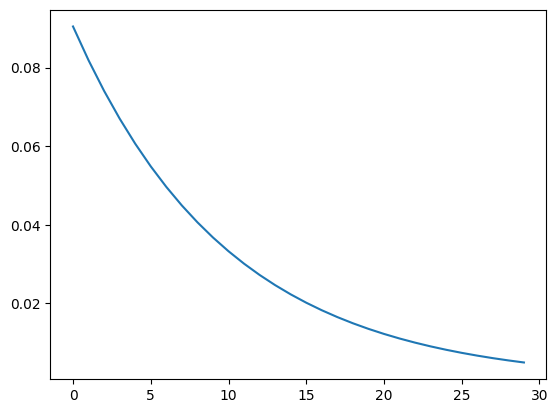

In [81]:
plt.plot(tf.range(30), [exp_scheduler(t)  for t in range(30)])
plt.show()

In [ ]:
def square_root(epoch, lr):
        return lr * pow(epoch + 1.0, -0.5)

class SquareRootScheduler:
    def __init__(self, lr=0.1):
        self.lr = lr

    def __call__(self, num_update):
        return self.lr * pow(num_update + 1.0, -0.5)

square_root_schedulaer = SquareRootScheduler(0.01)

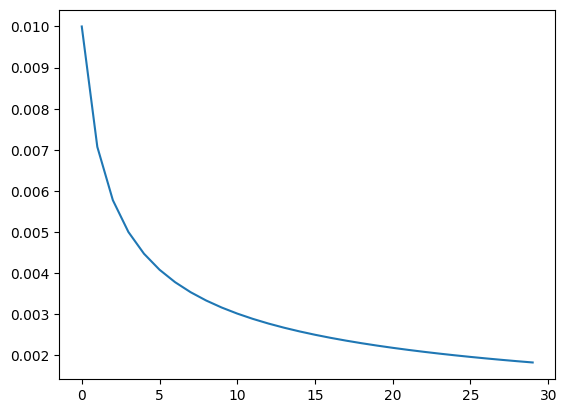

In [69]:
plt.plot(tf.range(30), [square_root(t, 0.01) for t in range(30)])
plt.show()

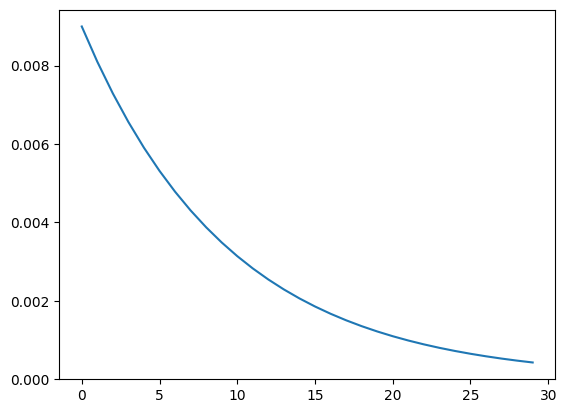

In [77]:
# Factor scheduler 
class FactorScheduler:
    def __init__(self, factor=1, stop_factor_lr=1e-7, base_lr=0.1):
        self.factor = factor
        self.stop_factor_lr = stop_factor_lr
        self.base_lr = base_lr

    def __call__(self, num_update):
        self.base_lr = max(self.stop_factor_lr, self.base_lr * self.factor)
        return self.base_lr

scheduler = FactorScheduler(factor=0.9, stop_factor_lr=1e-5, base_lr=0.01)
plt.plot(tf.range(30), [scheduler(t) for t in range(30)])

In [50]:
# Cosine Annealing (Most Popular)  ||  Smooth decay, widely used, great for most tasks
def cosine_schedule(epoch,lr):  #  CNN / MLP
    total_epochs = 10
    return lr * 0.5 * (1 + math.cos(math.pi * epoch / total_epochs))

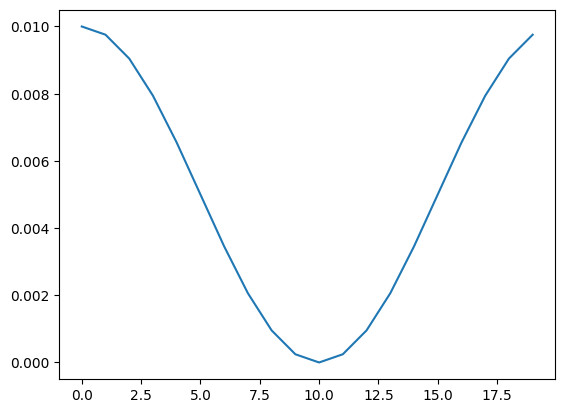

In [63]:
plt.plot(tf.range(20), [cosine_schedule(t, 0.01) for t in range(20)])
plt.show()

In [ ]:
# Warmup + Cosine Decay (Best Practice in modern ML) || Used in transformers, ResNets, most SOTA models

class WarmCosineScheduler:
    def __init__(self, max_update, base_lr=0.01, final_lr=0,
               warmup_steps=0, warmup_begin_lr=0):
        self.base_lr_orig = base_lr
        self.max_update = max_update
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps
        self.warmup_begin_lr = warmup_begin_lr
        self.max_steps = self.max_update - self.warmup_steps

    def get_warmup_lr(self, epoch):
        increase = (self.base_lr_orig - self.warmup_begin_lr) \
                       * float(epoch) / float(self.warmup_steps)
        return self.warmup_begin_lr + increase

    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            return self.get_warmup_lr(epoch)
        if epoch <= self.max_update:
            self.base_lr = self.final_lr + (
                self.base_lr_orig - self.final_lr) * (1 + math.cos(
                math.pi * (epoch - self.warmup_steps) / self.max_steps)) / 2
        return self.base_lr

warm_cos_scheduler = WarmCosineScheduler(max_update=20, base_lr=0.01, final_lr=0.00001)

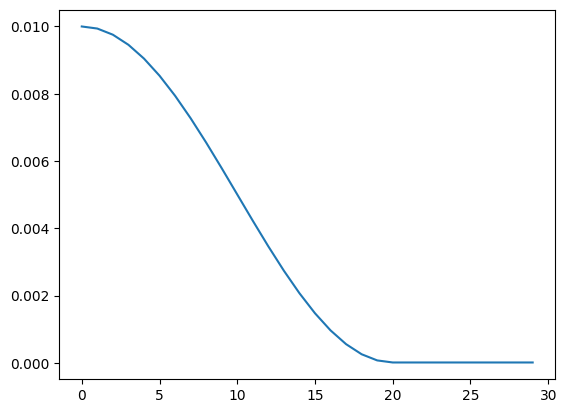

In [68]:
plt.plot(tf.range(30), [warm_cos_scheduler(t) for t in range(30)])

In [ ]:
# ReduceLROnPlateau (Adaptive — great for unknowns) || Reacts to actual training, no manual tuning needed — good default choice
# Don't know much about your data
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(  
    monitor='val_loss',
    factor=0.5,       # halve the LR
    patience=3,       # wait 3 epochs of no improvement
    min_lr=1e-6,
    verbose=1
) 